# Image Generation — Train examples, full Val set & full Test set
Load the best encoder checkpoint, run it on all three splits, and generate reconstructions with FLUX.1-dev + IP-Adapter.

In [1]:
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from config_const import CHECKPOINT_DIR, SIGLIP_DIM
from data_utils.rust_loader import make_rust_loader
from encoders import BottleneckMLP, TemporalLSTM, TemporalTransformer
from generation.flux_ipadapter import load_pipeline, generate
from generation.conditioning import neural_only
from get_device import get_device

## 1. Find best checkpoint

In [2]:
records = []
for pt in sorted(CHECKPOINT_DIR.rglob("best.pt")):
    ckpt = torch.load(pt, weights_only=False, map_location="cpu")
    row  = {**ckpt["args"], **ckpt["metrics"], "path": str(pt)}
    records.append(row)

best = max(records, key=lambda r: r.get("val_2afc", 0))
print(f"Best run:  {best['path']}")
print(f"  model={best['model']}  val_2afc={best['val_2afc']:.4f}  val_loss={best['val_loss']:.4f}")

Best run:  /home/yy3658/NeurObjectGen/checkpoints/mlp/bn128_do0.3_lr0.001_wd0.1_tn0.0_bs64_t0.07/best.pt
  model=mlp  val_2afc=0.8490  val_loss=3.1006


## 2. Load data

In [3]:
train_loader, val_loader, test_loader = make_rust_loader(use_embeddings=True)

neural_train, _ = next(iter(train_loader))  # (200, N, T) — shuffled; take first batch as examples
neural_val, _   = next(iter(val_loader))    # (50,  N, T) — full val set in one shot
neural_test, _  = next(iter(test_loader))   # (50,  N, T) — full test set in one shot

print(f"train batch: {neural_train.shape}  val: {neural_val.shape}  test: {neural_test.shape}")

Loading Rust sessions: 100%|██████████| 19/19 [00:23<00:00,  1.26s/it]
/home/yy3658/HexPred/object_response/get_rust_response.py:175: RuntimeWarning: Mean of empty slice
  avg_data[i] = np.nanmean(all_data[i], axis=0)
Loading Rust sessions: 100%|██████████| 10/10 [00:16<00:00,  1.65s/it]


RUST loaders created: train=200, val=50, test=50, neurons=6802, time=25, target=(1152,)
train batch: torch.Size([64, 6802, 25])  val: torch.Size([50, 6802, 25])  test: torch.Size([50, 6802, 25])


## 3. Rebuild encoder and load weights

In [4]:
device = get_device()
_, n_neurons, n_time = neural_val.shape
args = best

if args["model"] == "mlp":
    model = BottleneckMLP(
        in_dim=n_neurons * n_time,
        bottleneck=args["bottleneck"],
        out_dim=SIGLIP_DIM,
        dropout=args["dropout"],
    )
elif args["model"] == "lstm":
    model = TemporalLSTM(
        n_neurons=n_neurons,
        hidden=args["hidden"],
        out_dim=SIGLIP_DIM,
        dropout=args["dropout"],
    )
else:
    model = TemporalTransformer(
        n_neurons=n_neurons,
        d_model=args["d_model"],
        n_heads=args["n_heads"],
        n_layers=args["n_layers"],
        out_dim=SIGLIP_DIM,
        dropout=args["dropout"],
    )

ckpt = torch.load(best["path"], weights_only=False, map_location="cpu")
model.load_state_dict(ckpt["model_state"])
model.to(device).eval()
print(f"Loaded {model.__class__.__name__} from epoch {ckpt['epoch']}")

Loaded BottleneckMLP from epoch 122


## 4. Predict embeddings

In [5]:
def predict(neural: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        x = neural.to(device)
        if args["model"] == "mlp":
            x = x.flatten(1)
        else:
            x = x.permute(0, 2, 1)
        return model(x).cpu()

N_TRAIN_EXAMPLES = 10

embeds_train = predict(neural_train[:N_TRAIN_EXAMPLES])
embeds_val   = predict(neural_val)
embeds_test  = predict(neural_test)

print(f"train embeds: {embeds_train.shape}  val: {embeds_val.shape}  test: {embeds_test.shape}")

train embeds: torch.Size([10, 1152])  val: torch.Size([50, 1152])  test: torch.Size([50, 1152])


## 5. Load FLUX + IP-Adapter

In [6]:
pipe, ip_adapter = load_pipeline(device=device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

## 6. Generate — train examples

In [7]:
images_train = []
for i, emb in enumerate(embeds_train):
    img = generate(pipe, ip_adapter, show_progress=False, **neural_only(emb))
    images_train.append(img)
    print(f"  train [{i+1}/{len(embeds_train)}] done")

  train [1/10] done
  train [2/10] done
  train [3/10] done
  train [4/10] done
  train [5/10] done
  train [6/10] done
  train [7/10] done
  train [8/10] done
  train [9/10] done
  train [10/10] done


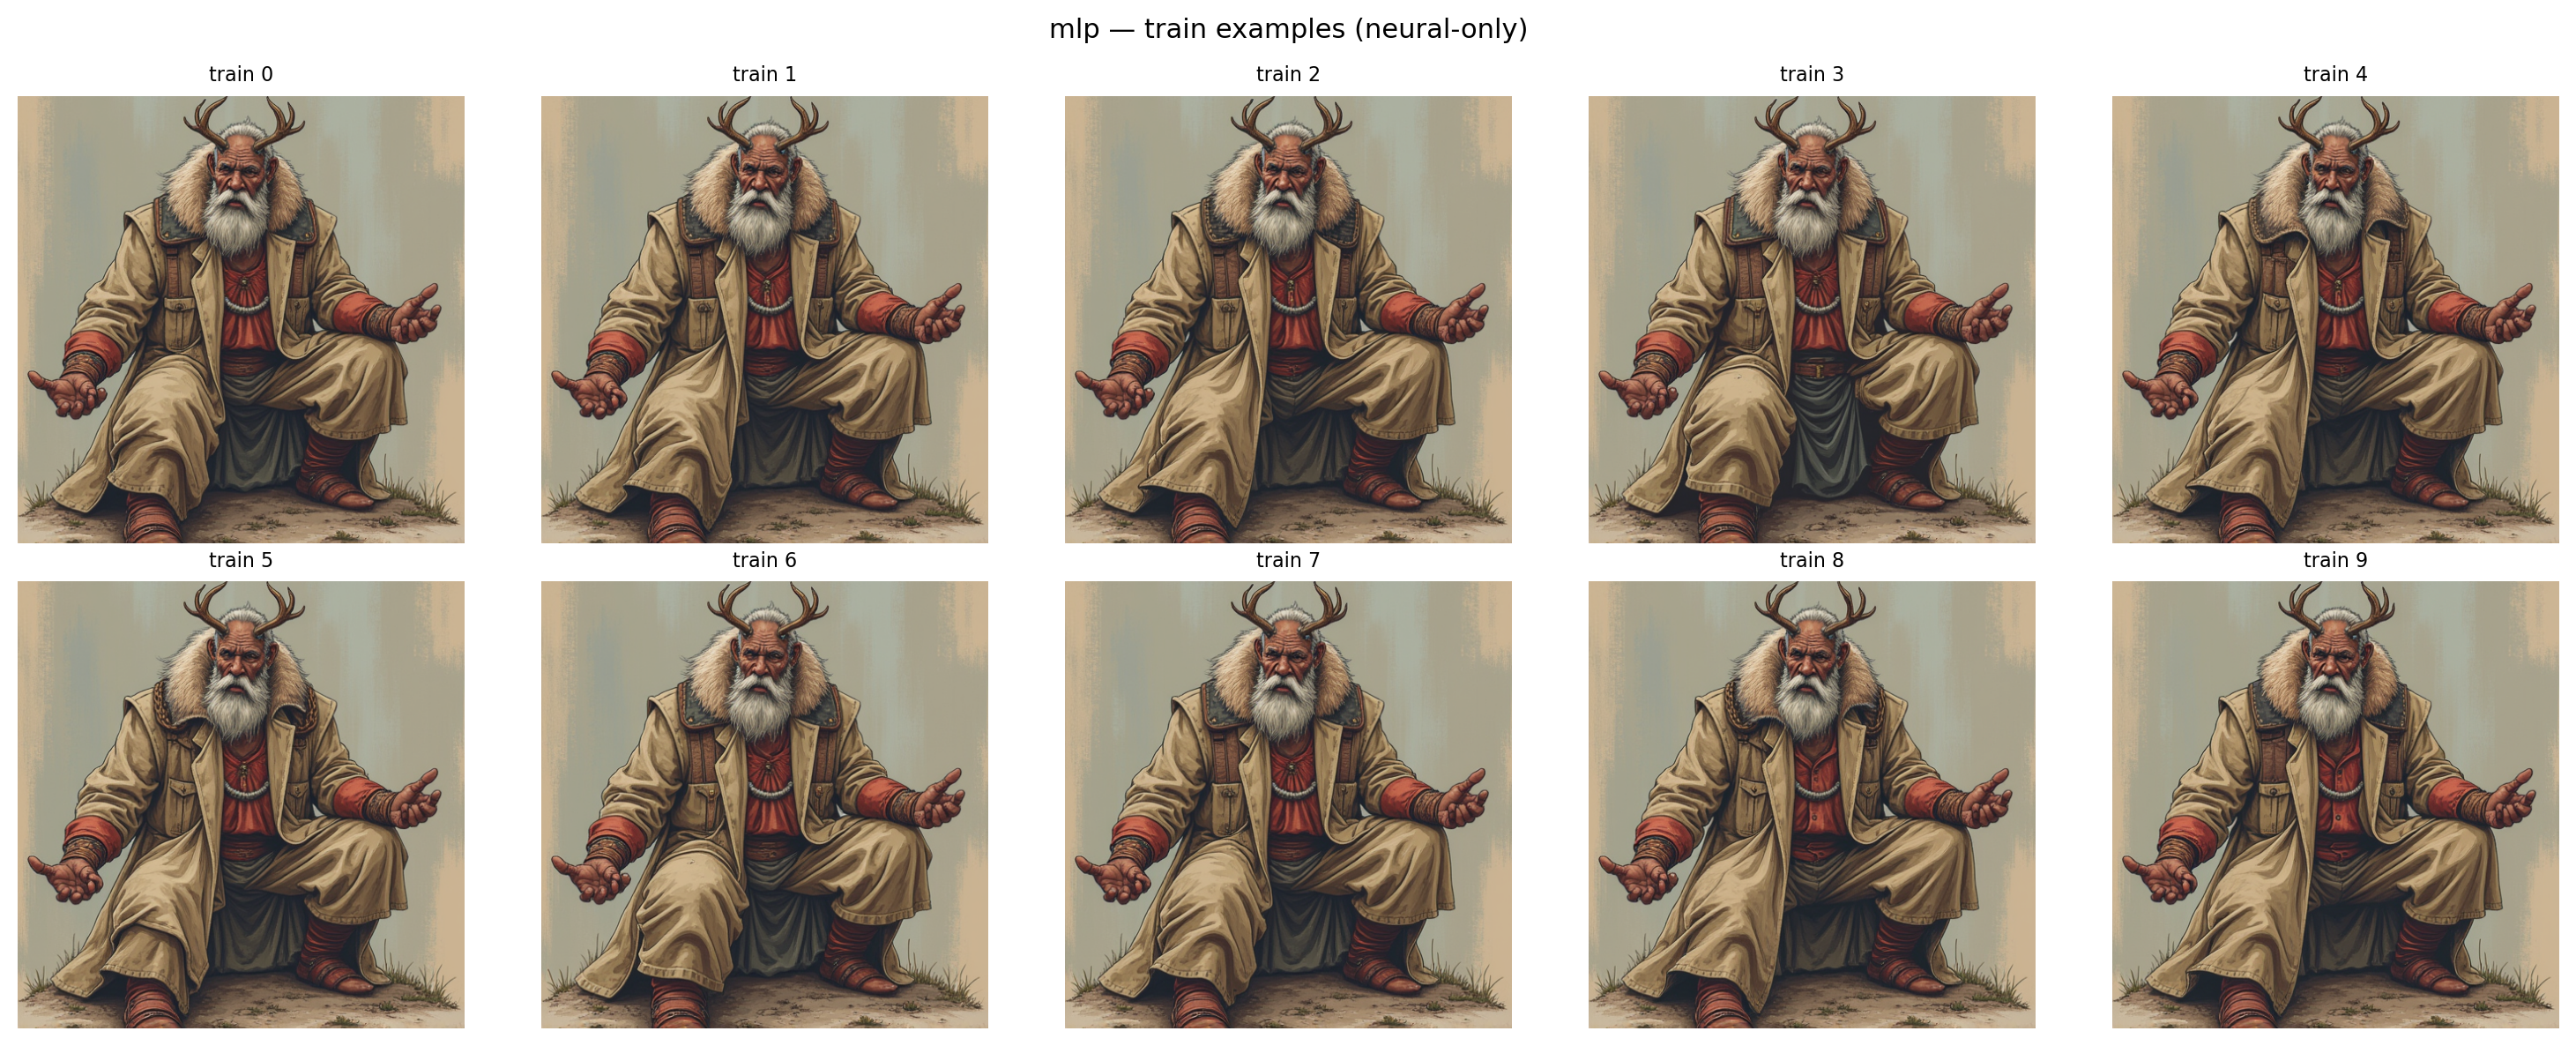

In [8]:
ncols = 5
nrows = (N_TRAIN_EXAMPLES + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
for ax in axes.flat:
    ax.axis("off")
for i, img in enumerate(images_train):
    axes.flat[i].imshow(img)
    axes.flat[i].set_title(f"train {i}", fontsize=8)
plt.suptitle(f"{args['model']} — train examples (neural-only)", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Generate — full val set (50 images)

In [ ]:
images_val = []
for i, emb in enumerate(embeds_val):
    img = generate(pipe, ip_adapter, show_progress=False, **neural_only(emb))
    images_val.append(img)
    print(f"  val [{i+1}/{len(embeds_val)}] done")

In [ ]:
ncols = 10
nrows = (len(images_val) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
for ax in axes.flat:
    ax.axis("off")
for i, img in enumerate(images_val):
    axes.flat[i].imshow(img)
    axes.flat[i].set_title(f"val {i}", fontsize=8)
plt.suptitle(f"{args['model']} — full val set (neural-only)", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Generate — full test set (50 images)

In [ ]:
images_test = []
for i, emb in enumerate(embeds_test):
    img = generate(pipe, ip_adapter, show_progress=False, **neural_only(emb))
    images_test.append(img)
    print(f"  test [{i+1}/{len(embeds_test)}] done")

In [ ]:
ncols = 10
nrows = (len(images_test) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
for ax in axes.flat:
    ax.axis("off")
for i, img in enumerate(images_test):
    axes.flat[i].imshow(img)
    axes.flat[i].set_title(f"test {i}", fontsize=8)
plt.suptitle(f"{args['model']} — full test set (neural-only)", fontsize=11)
plt.tight_layout()
plt.show()